# 05 — Strategy: 1-min selective entry + patient wait-for-TP

**One sentence.** At every 1-min boundary, open a small long BTC lot iff
(a) the model's probability is in the **top 5% of the training distribution**
AND (b) the virtual-ensemble **epistemic uncertainty is at or below the
training-median for that high-probability cohort**. Each lot holds a GTC TP
limit at `entry · exp(+phi)`; never closed at a loss.

**Differences vs. boundary-cadence v1**

- **Cadence**: 1-min (was: 20-min). Trades land in the same minute the model
  fires — no cadence-to-decision lag.
- **Label–execution alignment**: barrier source `"high"` — label trains the
  same event the simulator fills on (long TP at intra-bar high).
- **Selective entry**: two gates, both thresholds *frozen on training data*.
  Gate 1 = top-5% of training `p`; gate 2 = MI ≤ training-cohort median.

**Production discipline**

- Both thresholds derived on the training slice only; val/test never observed.
- Simulator runs val + test as one chronological stream.
- TP fill uses 1-min bar high → matches barrier_source="high".
- "Never close at loss" mechanic: no per-position SL, no bulk-close, no
  time-based expiry. The only exit is the deterministic TP limit fill.


In [1]:
from __future__ import annotations

import json
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "docs" / "MINIMAL_PROJECT_SPEC_v2.md").exists():
    if (ROOT.parent / "docs" / "MINIMAL_PROJECT_SPEC_v2.md").exists():
        ROOT = ROOT.parent
    else:
        raise RuntimeError("Could not locate repo root")
sys.path.insert(0, str(ROOT))

from src import utils
from src.analytics.thresholds import (
    derive_conditional_unc_cap,
    derive_top_q_threshold,
    summarize_gate_overlap,
)
from src.strategy.baseline import (
    COST_PER_TRADE,
    compute_btc_buy_and_hold,
)
from src.features.config import M as M_CFG, PHI as PHI_CFG
from src.strategy.cache import (
    augment_cache_with_boundary_ohlc,
    augment_cache_with_r_realized,
)
from src.strategy.policy import (
    RiskConfig,
    State,
    StrategySpec,
    exit_tp_or_expiry,
    gate_knowledge_unc_cap,
    gate_score_above,
    score_raw_p,
    size_clip,
    size_constant,
)
from src.strategy.simulator import SimConfig, simulate

DATASET_DIR = ROOT / "data" / "model_dataset"
CACHE_PATH = DATASET_DIR / "research_predictions_1min.parquet"
RAW_PATH = ROOT / "data" / "raw_data" / "klines_1m.parquet"
TRAIN_ART_PATH = DATASET_DIR / "analytics" / "train_scores_unc_1min.parquet"
VAL_TEST_ART_PATH = DATASET_DIR / "analytics" / "val_test_ve_unc_1min.parquet"
OUT_DIR = DATASET_DIR / "strategy" / "production_1min_selective"
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")
warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.titleweight": "bold",
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
M = int(M_CFG)
PHI = float(PHI_CFG)
print(f"ROOT        : {ROOT}")
print(f"M, PHI      : {M}, {PHI}")
print(f"OUT_DIR     : {OUT_DIR}")


ROOT        : C:\Users\vitil\OneDrive\Desktop\barrier_classifier
M, PHI      : 20, 0.0025
OUT_DIR     : C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\strategy\production_1min_selective


## 1. Frozen-from-training thresholds

Both knobs come **only** from the training slice.

- `P_95` = 95th percentile of training-period scores → score gate.
- `U_cap` = median of `knowledge_unc` among training rows with `p >= P_95`
  → epistemic gate, conditional on the score cohort.


In [2]:
TOP_Q = 0.95          # score gate: top 5% of training p
UNC_Q_COND = 0.50     # epistemic gate: median of MI among score-passing rows
LOT_SIZE = 0.02       # 2% of capital per lot
MAX_CONCURRENT = 50   # 50 * 0.02 = 100% gross cap
COST = COST_PER_TRADE  # 5 bp round-trip (canonical from src.strategy.baseline)
MAX_HORIZON_BOUNDARIES = 1_000_000   # effectively no time-based expiry

train_art = pd.read_parquet(TRAIN_ART_PATH)
p_train = train_art['p_train'].to_numpy()
unc_train = train_art['knowledge_unc_train'].to_numpy()
print(f"Training slice loaded: {len(train_art):,} rows  k=[{train_art['k'].min()}, {train_art['k'].max()}]")

P_95 = derive_top_q_threshold(p_train, q=TOP_Q)
U_cap = derive_conditional_unc_cap(p_train, unc_train, p_threshold=P_95, q=UNC_Q_COND)
overlap = summarize_gate_overlap(p_train, unc_train, p_threshold=P_95, unc_cap=U_cap)

print()
print(f"P_95 (score gate)              = {P_95:.4f}")
print(f"U_cap (conditional MI median)  = {U_cap:.6f}")
print(f"Training rows passing score    : {overlap['n_score_pass']:,} of {overlap['n_train']:,}  ({overlap['score_pass_rate']*100:.2f}%)")
print(f"Training rows passing both     : {overlap['n_joint_pass']:,}                       ({overlap['joint_pass_rate']*100:.2f}%)")
print(f"Conditional pass-rate          : {overlap['unc_pass_rate_given_score']*100:.2f}%  of score-passers")


Training slice loaded: 353,794 rows  k=[20159, 373952]

P_95 (score gate)              = 0.3538
U_cap (conditional MI median)  = 0.000000
Training rows passing score    : 17,690 of 353,794  (5.00%)
Training rows passing both     : 13,159                       (3.72%)
Conditional pass-rate          : 74.39%  of score-passers


## 2. Load 1-min cache; augment with VE + OHLC

Cache columns from `train_1min_model.py`: `k, ts, y, m_k, tau_k, phi, regime,
p, split`. We attach:
- `mean_p_ve, knowledge_unc` from the val+test precompute artifact.
- `open / high / low / close` joined from `raw_data/klines_1m.parquet`.
- `r_realized` for any downstream analytics.


In [3]:
cache = pd.read_parquet(CACHE_PATH)
print(f"Cache (val+test): {len(cache):,} rows  splits={cache['split'].value_counts().to_dict()}")

ve_art = pd.read_parquet(VAL_TEST_ART_PATH)
cache = cache.merge(ve_art, on=['k', 'split'], how='left')
assert cache['knowledge_unc'].notna().all(), "VE merge left NaNs — precompute is misaligned"

raw_bars = pd.read_parquet(RAW_PATH, columns=['open', 'high', 'low', 'close'])
if raw_bars.index.tz is not None:
    raw_bars.index = raw_bars.index.tz_localize(None)
print(f"Raw bars: {len(raw_bars):,}  {raw_bars.index.min()} -> {raw_bars.index.max()}")

cache = augment_cache_with_boundary_ohlc(cache, raw_bars)
cache = augment_cache_with_r_realized(cache, raw_bars, M=M)
print(f"Augmented cache columns: {list(cache.columns)}")


Cache (val+test): 149,227 rows  splits={'test': 74614, 'val': 74613}
Raw bars: 525,600  2025-01-01 00:01:00 -> 2026-01-01 00:00:00


Augmented cache columns: ['k', 'ts', 'y', 'm_k', 'tau_k', 'phi', 'regime', 'p', 'split', 'mean_p_ve', 'knowledge_unc', 'open', 'high', 'low', 'close', 'r_realized']


## 3. Build the patient wait-for-TP spec with selective gates

Two AND-composed entry gates:
1. `gate_score_above(s, P_95)` — score in top 5% of training distribution.
2. `gate_knowledge_unc_cap(s, U_cap)` — MI ≤ training-conditional median.

Sizing: fixed `lot_size = 0.02` per fire; cap at `max_open = 50` lots.

**No bulk-close, no per-position SL, no time-based expiry.** Positions
exit ONLY when the +phi TP limit fills. Underwater lots wait indefinitely.

(Spec wired by hand — NOT via `make_1min_cluster_aware_spec`, which bakes in
a `cluster_loss_cap` circuit breaker that contradicts the never-close-at-loss rule.)


In [4]:
sim_cache = (
    pd.concat([cache[cache['split']=='val'], cache[cache['split']=='test']])
    .sort_values('ts').reset_index(drop=True)
)
val_test_boundary = pd.Timestamp(cache[cache['split']=='test']['ts'].min())
print(f"Live stream  : {sim_cache['ts'].min()} -> {sim_cache['ts'].max()}  ({len(sim_cache):,} rows at 1-min)")
print(f"val | test ts: {val_test_boundary}")

spec = StrategySpec(
    name='selective_patient_wait_for_tp_1min',
    requires=('ve_diag',),
    score_fn=score_raw_p,
    entry_gates=(
        lambda s, t=P_95: gate_score_above(s, t),
        lambda s, c=U_cap: gate_knowledge_unc_cap(s, c),
    ),
    sizer=lambda s, sz=LOT_SIZE: size_clip(size_constant(s, default=sz), max_size=1.0),
    exit_policy=exit_tp_or_expiry,
    bulk_close=lambda s: None,
    risk=RiskConfig(
        cost_per_trade=COST,
        max_open_positions=MAX_CONCURRENT,
        max_gross_size=MAX_CONCURRENT * LOT_SIZE + 1e-6,
        max_horizon_boundaries=MAX_HORIZON_BOUNDARIES,
        position_mtm_floor_log_return=None,
    ),
    description=(
        "top-5% selective entry (p>=P_95 AND unc<=U_cap) + patient wait-for-TP; never close at loss"
    ),
)
print(f"\nSpec: {spec.name}  requires={spec.requires}  entry_gates={len(spec.entry_gates)}")

cfg = SimConfig(M=M)
t0 = time.perf_counter()
result = simulate(sim_cache, raw_bars, spec, config=cfg)
print(f"Simulator: {time.perf_counter()-t0:.1f}s  trades closed={len(result.closed):,}  open at end={int(result.equity['n_open'].iloc[-1])}")


Live stream  : 2025-09-18 12:34:00 -> 2025-12-31 23:40:00  (149,227 rows at 1-min)
val | test ts: 2025-11-10 04:07:00

Spec: selective_patient_wait_for_tp_1min  requires=('ve_diag',)  entry_gates=2


Simulator: 209.6s  trades closed=1,047  open at end=50


## 4. Headline metrics

Realized P&L is a one-way ratchet by construction (every closed trade is
a +TP fill). Calmar (annualized realized / worst total-equity drawdown)
is the honest single-number; Sharpe-of-realized is inflated for ratchet
strategies and is reported for completeness only.


In [5]:
eq = result.equity.copy()
eq['ts'] = pd.to_datetime(eq['ts'])
span_days = (eq['ts'].max() - eq['ts'].min()).total_seconds() / 86400.0

eq_idx = eq.set_index('ts')
daily = eq_idx['realized_cum'].resample('1D').last().ffill()
daily_ret = daily.diff().fillna(daily.iloc[0])
annualized_realized = float(daily.iloc[-1]) * (365.0 / span_days)
sharpe_realized = (
    float(daily_ret.mean() / daily_ret.std() * np.sqrt(365.0))
    if daily_ret.std() > 1e-18 else float('nan')
)

GROSS_CAP = MAX_CONCURRENT * LOT_SIZE
eq['utilization'] = eq['gross_size'] / GROSS_CAP
peak_util = float(eq['utilization'].max())
avg_util = float(eq['utilization'].mean())
peak_concurrent = int(eq['n_open'].max())

total_eq = (eq['realized_cum'] + eq['unrealized']).to_numpy()
peaks = np.maximum.accumulate(total_eq)
dd_series = total_eq - peaks
max_paper_dd = float(-dd_series.min())
worst_dd_idx = int(np.argmin(dd_series))
worst_dd_ts = eq['ts'].iloc[worst_dd_idx]

btc_log_return, btc_annualized = compute_btc_buy_and_hold(
    raw_bars, eq['ts'].min(), eq['ts'].max(), span_days=span_days,
)

calmar = annualized_realized / max_paper_dd if max_paper_dd > 0 else float('inf')

summary = pd.DataFrame([
    {'metric': 'Deployment span (days)',           'value': f'{span_days:.1f}'},
    {'metric': '1-min boundaries simulated',       'value': f'{len(eq):,}'},
    {'metric': 'Signals fired (entries)',          'value': f"{int(eq['opened_this_step'].sum()):,}"},
    {'metric': 'TPs filled',                       'value': f"{int((result.closed['exit_reason']=='tp').sum()):,}" if len(result.closed) else "0"},
    {'metric': 'Still open at end',                'value': f"{int(eq['n_open'].iloc[-1]):,}"},
    {'metric': 'Realized log-return (cumulative)', 'value': f"{float(daily.iloc[-1])*100:+.3f}%"},
    {'metric': 'Realized annualized',              'value': f"{annualized_realized*100:+.2f}%"},
    {'metric': 'Daily-Sharpe of realized',         'value': f"{sharpe_realized:.2f}"},
    {'metric': 'Calmar (ann. realized / max DD)',  'value': f"{calmar:.2f}"},
    {'metric': 'Worst paper DD on total equity',   'value': f"{max_paper_dd*100:.2f}%  (at {worst_dd_ts.strftime('%Y-%m-%d %H:%M')})"},
    {'metric': 'Unrealized at end-of-period',      'value': f"{float(eq['unrealized'].iloc[-1])*100:+.3f}%"},
    {'metric': 'Avg capital deployed',             'value': f"{avg_util*100:.1f}%"},
    {'metric': 'Peak capital deployed',            'value': f"{peak_util*100:.1f}%  (peak lot count {peak_concurrent})"},
    {'metric': 'BTC B&H over same span',           'value': f"{btc_log_return*100:+.2f}%  ({btc_annualized*100:+.1f}%/yr)"},
    {'metric': 'P_95 (score gate)',                'value': f"{P_95:.4f}"},
    {'metric': 'U_cap (epistemic gate)',           'value': f"{U_cap:.6f}"},
])
display(summary.style.hide(axis='index'))

prod_summary = {
    'span_days': span_days,
    'n_signals': int(eq['opened_this_step'].sum()),
    'n_tps': int((result.closed['exit_reason']=='tp').sum()) if len(result.closed) else 0,
    'n_open_at_end': int(eq['n_open'].iloc[-1]),
    'realized_log_return': float(daily.iloc[-1]),
    'realized_annualized': annualized_realized,
    'sharpe_realized_daily': sharpe_realized,
    'calmar': calmar,
    'max_paper_dd': max_paper_dd,
    'worst_dd_ts': str(worst_dd_ts),
    'unrealized_at_end': float(eq['unrealized'].iloc[-1]),
    'avg_utilization': avg_util,
    'peak_utilization': peak_util,
    'peak_concurrent': peak_concurrent,
    'btc_log_return': btc_log_return,
    'btc_annualized': btc_annualized,
    'parameters': {
        'P_95': float(P_95), 'U_cap': float(U_cap),
        'TOP_Q': TOP_Q, 'UNC_Q_COND': UNC_Q_COND,
        'lot_size': LOT_SIZE, 'max_concurrent': MAX_CONCURRENT,
        'phi': PHI, 'cost': COST,
    },
}
with open(OUT_DIR / 'production_summary.json', 'w') as f:
    json.dump(prod_summary, f, indent=2, default=str)
print(f"\nSaved: {OUT_DIR / 'production_summary.json'}")


metric,value
Deployment span (days),104.5
1-min boundaries simulated,"149,227"
Signals fired (entries),"1,097"
TPs filled,"1,047"
Still open at end,50
Realized log-return (cumulative),+4.188%
Realized annualized,+14.63%
Daily-Sharpe of realized,9.42
Calmar (ann. realized / max DD),0.50
Worst paper DD on total equity,29.26% (at 2025-11-21 12:29)



Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\strategy\production_1min_selective\production_summary.json


## 5. Main dashboard — time-aligned stack at 1-min frequency

Seven panels sharing one x-axis. Plotted at native 1-min cadence.

| Panel | Reads as |
|---|---|
| BTC close | market regime context |
| Equity (realized + unrealized + total) | the deliverable |
| Drawdown on total equity | pain timing — does DD precede or follow clusters? |
| Portfolio composition (depth-bin stack) | book health — in this design the ITM band is thin by construction (TP closes lots immediately when they cross +phi) |
| Score `p` + threshold | when did the score gate fire? red dots = score-pass / unc-block |
| Knowledge unc + cap | when did the epistemic gate cut into the firing set? |
| Position swimlane | per-trade lifetime distribution over the span |

Vertical dotted: val | test boundary. Vertical dot-dash: worst-DD timestamp.


In [6]:
# Continuous BTC series over the deployment span
deploy_start, deploy_end = eq['ts'].min(), eq['ts'].max()
btc_slice = raw_bars.loc[(raw_bars.index >= deploy_start) & (raw_bars.index <= deploy_end), 'close']
btc_idx = btc_slice.index

# Composition bins by current MTM in log-return space.
# TP at +25bp = +PHI, so an open position's MTM is in [-inf, +phi).
BIN_EDGES = [-np.inf, -0.020, -0.010, -0.005, -0.0025, 0.0, 0.0025]
BIN_LABELS = ['< -2% (stressed)', '-2% to -1%', '-1% to -50bp', '-50bp to -25bp', '-25bp to 0', '0 to +25bp (ITM, thin)']
BIN_COLORS = ['#7a0d0d', '#c0392b', '#e67e22', '#f1c40f', '#7fbf7b', '#2ecc71']

closed = result.closed.copy()
if len(closed):
    closed['ts_entry'] = pd.to_datetime(closed['ts_entry']).map(lambda x: x.tz_localize(None) if getattr(x, 'tz', None) is not None else x)
    closed['ts_exit'] = pd.to_datetime(closed['ts_exit']).map(lambda x: x.tz_localize(None) if getattr(x, 'tz', None) is not None else x)

def reconstruct_composition_fast(eq_df, closed_df, raw_bars_df, bin_edges, n_bins):
    eq_ts = pd.to_datetime(eq_df['ts'].values)
    n = len(eq_ts)
    counts = np.zeros((n, n_bins), dtype=int)
    sum_mtm = np.zeros(n, dtype=float)
    n_open_arr = np.zeros(n, dtype=int)
    worst_mtm_arr = np.full(n, np.nan, dtype=float)
    if len(closed_df) == 0:
        return counts, sum_mtm, n_open_arr, worst_mtm_arr
    close_series = raw_bars_df['close'].reindex(pd.DatetimeIndex(eq_ts), method='ffill')
    close_arr = close_series.to_numpy(dtype=float)
    eq_idx_local = pd.DatetimeIndex(eq_ts)
    edges = np.asarray(bin_edges)
    for _, tr in closed_df.iterrows():
        i0 = int(eq_idx_local.searchsorted(tr['ts_entry'], side='right') - 1)
        i1 = int(eq_idx_local.searchsorted(tr['ts_exit'], side='right') - 1)
        i0 = max(0, i0); i1 = min(n - 1, i1)
        if i1 < i0:
            continue
        ep = float(tr['entry_price'])
        if ep <= 0:
            continue
        mtm = np.log(close_arr[i0:i1+1] / ep)
        bin_ix = np.clip(np.digitize(mtm, edges) - 1, 0, n_bins - 1)
        rng = np.arange(i0, i1 + 1)
        for k_idx, b in zip(rng, bin_ix):
            counts[k_idx, b] += 1
        sum_mtm[rng] += mtm
        n_open_arr[rng] += 1
        worst_mtm_arr[rng] = np.where(
            np.isnan(worst_mtm_arr[rng]), mtm, np.fmin(worst_mtm_arr[rng], mtm)
        )
    return counts, sum_mtm, n_open_arr, worst_mtm_arr

t0 = time.perf_counter()
counts, sum_mtm, n_open_arr, worst_mtm_arr = reconstruct_composition_fast(
    eq, closed, raw_bars, BIN_EDGES, len(BIN_LABELS),
)
print(f"Composition reconstruction: {time.perf_counter()-t0:.1f}s ({len(eq):,} steps, {len(closed):,} trades)")


Composition reconstruction: 0.1s (149,227 steps, 1,047 trades)


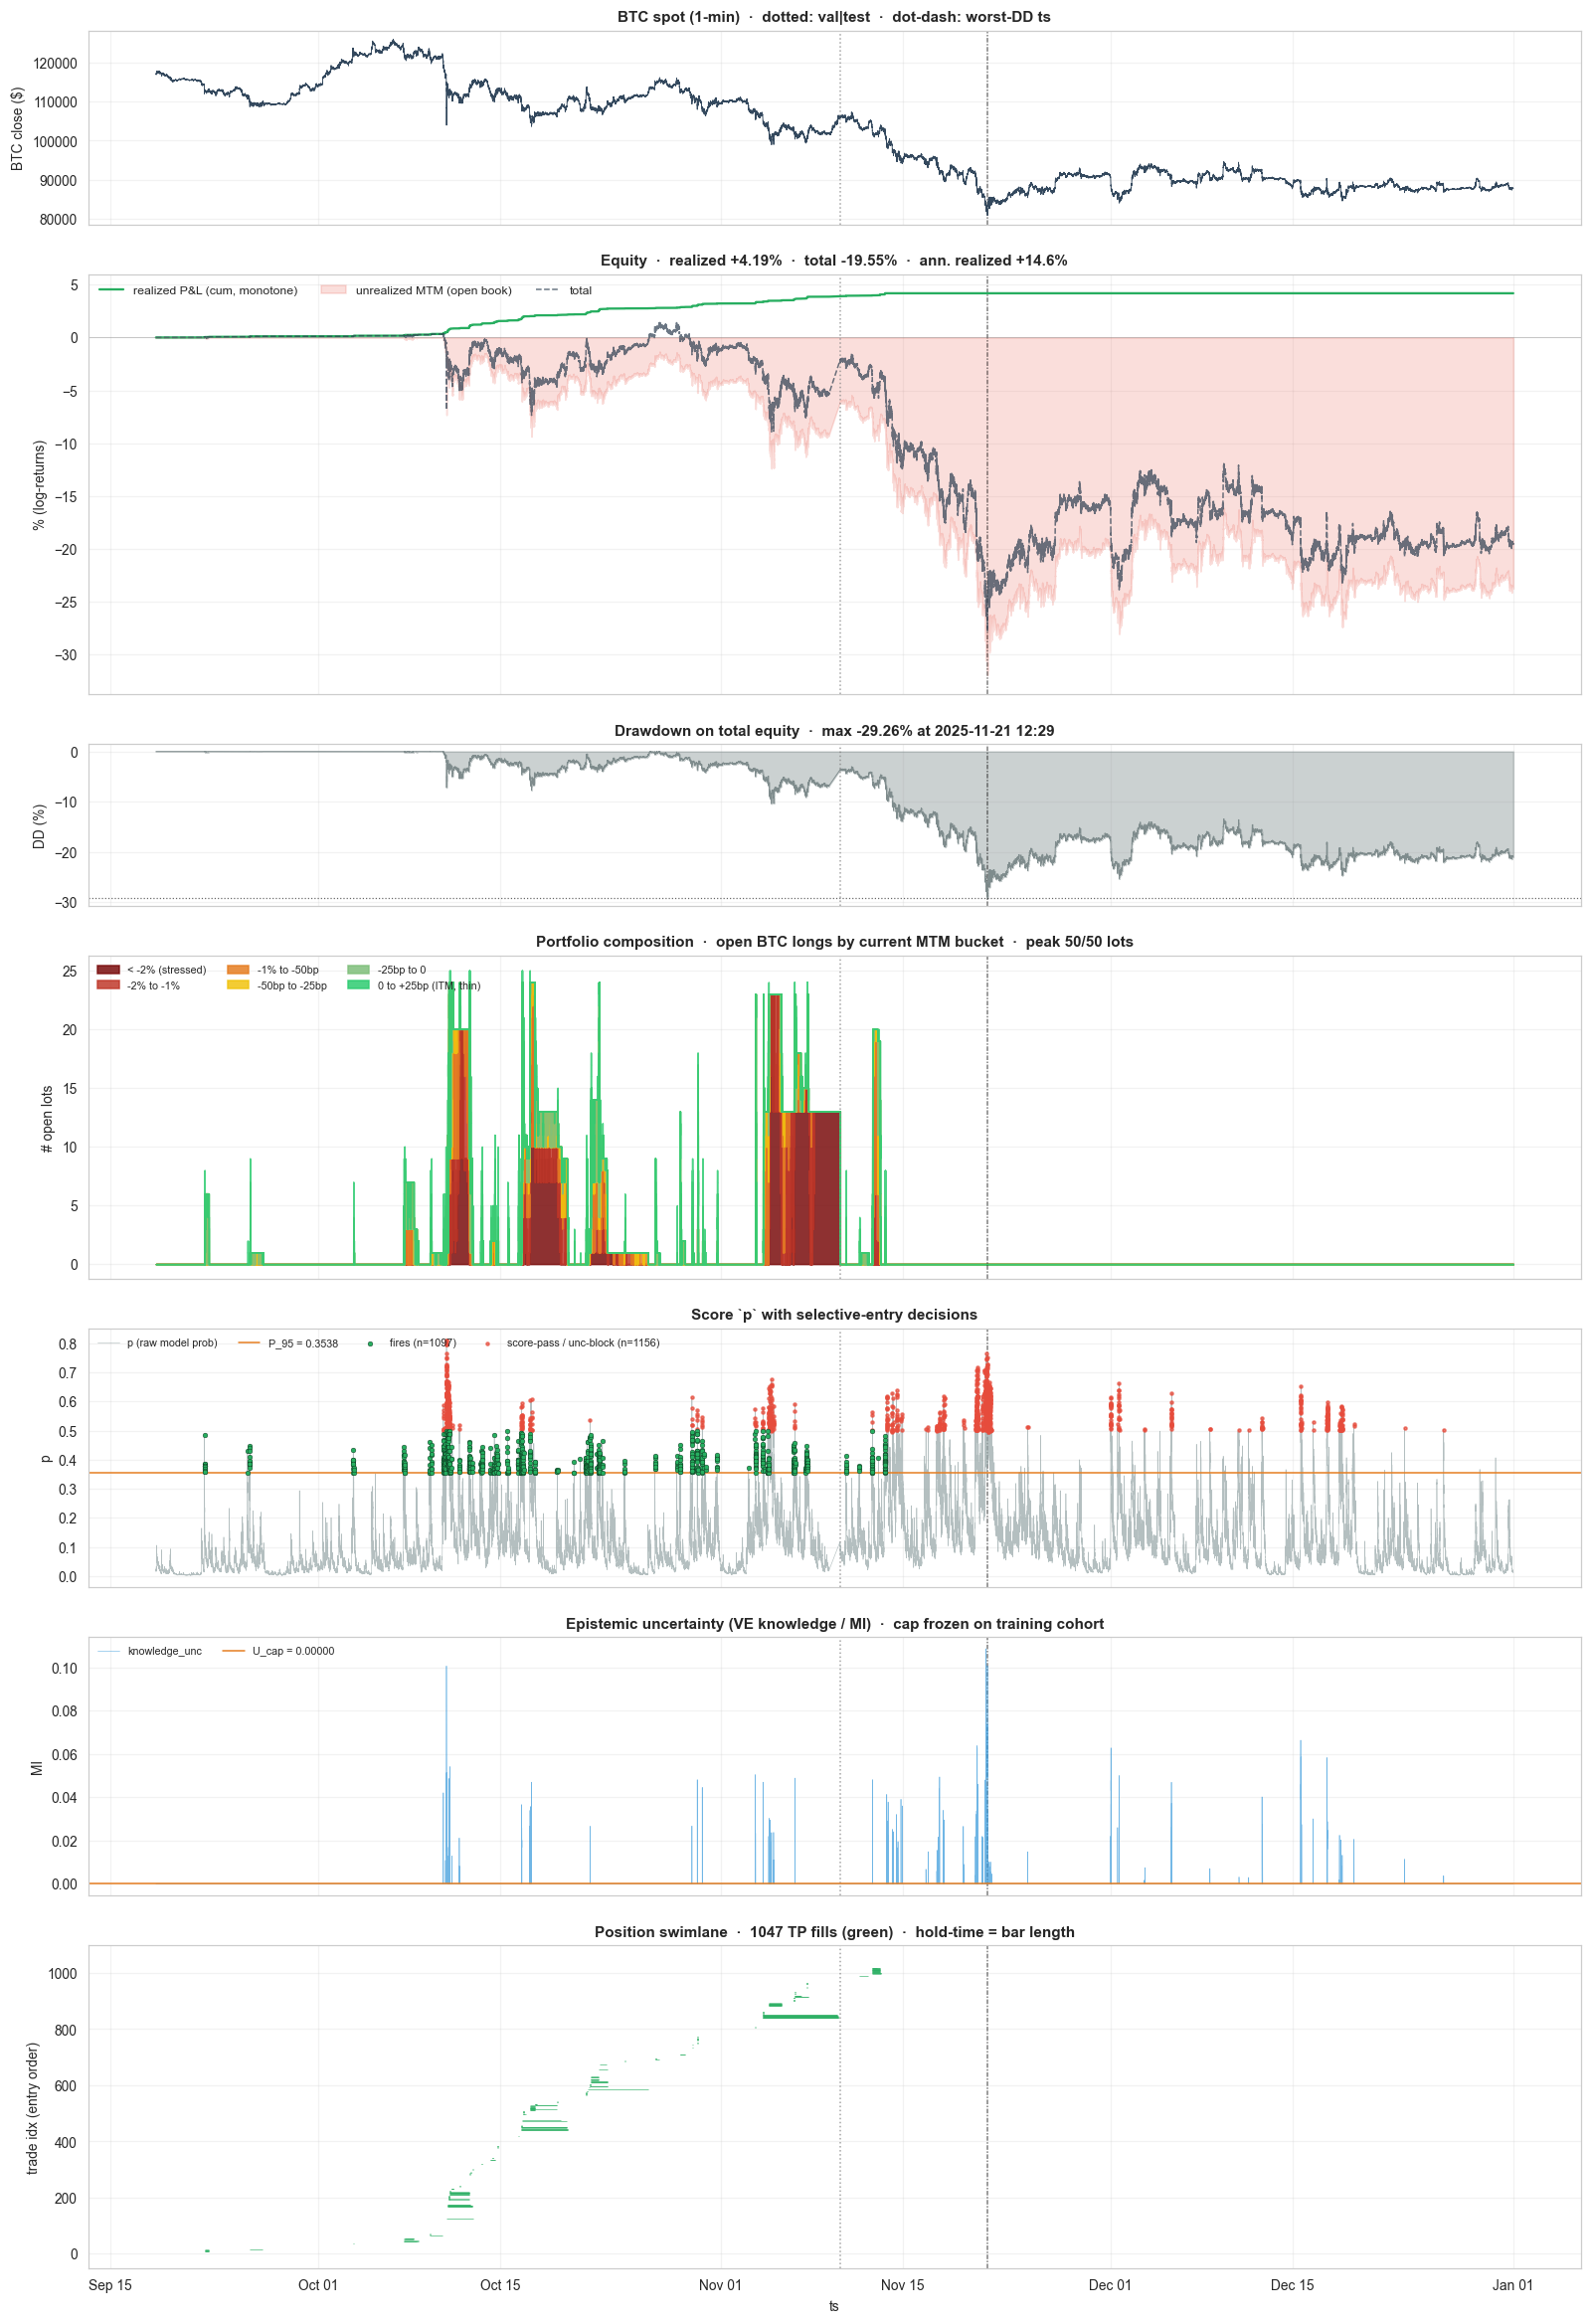

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\strategy\production_1min_selective\dashboard.png


In [7]:
# ---- DASHBOARD: 7-panel time-aligned stack ------------------------------
fig = plt.figure(figsize=(15, 22))
gs = gridspec.GridSpec(
    nrows=7, ncols=1, figure=fig,
    height_ratios=[1.2, 2.6, 1.0, 2.0, 1.6, 1.6, 2.0],
    hspace=0.18, top=0.97, bottom=0.04, left=0.06, right=0.97,
)
ax_btc   = fig.add_subplot(gs[0])
ax_eq    = fig.add_subplot(gs[1], sharex=ax_btc)
ax_dd    = fig.add_subplot(gs[2], sharex=ax_btc)
ax_comp  = fig.add_subplot(gs[3], sharex=ax_btc)
ax_score = fig.add_subplot(gs[4], sharex=ax_btc)
ax_unc   = fig.add_subplot(gs[5], sharex=ax_btc)
ax_swim  = fig.add_subplot(gs[6], sharex=ax_btc)
all_axes = [ax_btc, ax_eq, ax_dd, ax_comp, ax_score, ax_unc, ax_swim]
for a in all_axes:
    a.axvline(val_test_boundary, color='gray', linestyle=':', linewidth=1, alpha=0.7)
    a.axvline(worst_dd_ts, color='black', linestyle=(0, (3, 1, 1, 1)), linewidth=1, alpha=0.5)

ax_btc.plot(btc_idx, btc_slice.values, color='#34495e', linewidth=0.6)
ax_btc.set_ylabel('BTC close ($)')
ax_btc.set_title('BTC spot (1-min)  ·  dotted: val|test  ·  dot-dash: worst-DD ts')

realized = eq['realized_cum'].to_numpy() * 100
unreal = eq['unrealized'].to_numpy() * 100
total = realized + unreal
ax_eq.plot(eq['ts'], realized, color='#27ae60', linewidth=1.5, label='realized P&L (cum, monotone)')
ax_eq.fill_between(eq['ts'], 0, unreal, color='#e74c3c', alpha=0.18, label='unrealized MTM (open book)')
ax_eq.plot(eq['ts'], total, color='#2c3e50', linestyle='--', linewidth=1.0, alpha=0.7, label='total')
ax_eq.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax_eq.set_ylabel('% (log-returns)')
ax_eq.set_title(f"Equity  ·  realized {realized[-1]:+.2f}%  ·  total {total[-1]:+.2f}%  ·  ann. realized {annualized_realized*100:+.1f}%")
ax_eq.legend(loc='upper left', ncol=3, frameon=False)

dd_pct = dd_series * 100
ax_dd.fill_between(eq['ts'], 0, dd_pct, color='#7f8c8d', alpha=0.4)
ax_dd.plot(eq['ts'], dd_pct, color='#7f8c8d', linewidth=0.5)
ax_dd.axhline(-max_paper_dd*100, color='black', linestyle=':', linewidth=0.8, alpha=0.6)
ax_dd.set_ylabel('DD (%)')
ax_dd.set_title(f"Drawdown on total equity  ·  max {-max_paper_dd*100:.2f}% at {worst_dd_ts.strftime('%Y-%m-%d %H:%M')}")

ts_arr = eq['ts'].values
bottom = np.zeros(len(eq))
for b in range(len(BIN_LABELS)):
    ax_comp.fill_between(ts_arr, bottom, bottom + counts[:, b],
                         color=BIN_COLORS[b], alpha=0.85, label=BIN_LABELS[b], step='post')
    bottom = bottom + counts[:, b]
ax_comp.set_ylabel('# open lots')
ax_comp.set_title(f"Portfolio composition  ·  open BTC longs by current MTM bucket  ·  peak {peak_concurrent}/{MAX_CONCURRENT} lots")
ax_comp.legend(loc='upper left', ncol=3, frameon=False, fontsize=7)

ax_score.plot(eq['ts'], eq['p'], color='#95a5a6', linewidth=0.4, alpha=0.7, label='p (raw model prob)')
ax_score.axhline(P_95, color='#e67e22', linestyle='-', linewidth=1.0, label=f'P_95 = {P_95:.4f}')
fired = eq[eq['opened_this_step'].astype(bool)]
ax_score.scatter(fired['ts'], fired['p'], s=10, color='#27ae60', edgecolor='black', linewidth=0.2, zorder=3, label=f'fires (n={len(fired)})')
blocked = eq[(eq['p'] >= P_95) & (eq['knowledge_unc'] > U_cap) & (~eq['opened_this_step'].astype(bool))]
ax_score.scatter(blocked['ts'], blocked['p'], s=4, color='#e74c3c', alpha=0.7, zorder=2, label=f'score-pass / unc-block (n={len(blocked)})')
ax_score.set_ylabel('p')
ax_score.set_title('Score `p` with selective-entry decisions')
ax_score.legend(loc='upper left', ncol=4, frameon=False, fontsize=7)

ax_unc.plot(eq['ts'], eq['knowledge_unc'], color='#3498db', linewidth=0.4, alpha=0.7, label='knowledge_unc')
ax_unc.axhline(U_cap, color='#e67e22', linestyle='-', linewidth=1.0, label=f'U_cap = {U_cap:.5f}')
ax_unc.set_ylabel('MI')
ax_unc.set_title('Epistemic uncertainty (VE knowledge / MI)  ·  cap frozen on training cohort')
ax_unc.legend(loc='upper left', ncol=2, frameon=False, fontsize=7)

if len(closed) > 0:
    closed_sorted = closed.sort_values('ts_entry').reset_index(drop=True)
    for i, tr in closed_sorted.iterrows():
        color = '#27ae60' if tr['exit_reason'] == 'tp' else '#bdc3c7'
        ax_swim.hlines(i, tr['ts_entry'], tr['ts_exit'], color=color, alpha=0.65, linewidth=0.6)
ax_swim.set_ylabel('trade idx (entry order)')
n_tp_swim = int((result.closed['exit_reason']=='tp').sum()) if len(result.closed) else 0
ax_swim.set_title(f"Position swimlane  ·  {n_tp_swim} TP fills (green)  ·  hold-time = bar length")
ax_swim.set_xlabel('ts')

for a in all_axes[:-1]:
    plt.setp(a.get_xticklabels(), visible=False)
ax_swim.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=10))
ax_swim.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

fig.savefig(OUT_DIR / 'dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUT_DIR / 'dashboard.png'}")


## 6. Trade-window zoom-ins — are entries at local minima?

Grid of 16 trades, each showing raw 1-min close ±60 min around entry,
entry & TP fill markers, and the TP target line. Samples: 4 fastest, 4
slowest, 4 deepest worst-MTM before recovering, 4 random.


In [8]:
def _select_trade_sample(closed_df, n_per_group=4, seed=0):
    if len(closed_df) == 0:
        return closed_df
    df = closed_df.copy()
    df['hold_min'] = (df['ts_exit'] - df['ts_entry']).dt.total_seconds() / 60.0
    raw_idx_local = raw_bars.index
    raw_low_arr = raw_bars['low'].to_numpy()
    worst = np.zeros(len(df))
    for i, (_, tr) in enumerate(df.iterrows()):
        lo = int(np.searchsorted(raw_idx_local, np.datetime64(tr['ts_entry']), side='right'))
        hi = int(np.searchsorted(raw_idx_local, np.datetime64(tr['ts_exit']), side='right'))
        if hi > lo:
            worst[i] = float(np.log(raw_low_arr[lo:hi].min() / tr['entry_price']))
    df['worst_mtm'] = worst
    fastest = df.nsmallest(n_per_group, 'hold_min')
    slowest = df.nlargest(n_per_group, 'hold_min')
    deepest = df.nsmallest(n_per_group, 'worst_mtm')
    rng = np.random.default_rng(seed)
    random_idx = rng.choice(df.index, size=min(n_per_group, len(df)), replace=False)
    randoms = df.loc[random_idx]
    selected = pd.concat([fastest, slowest, deepest, randoms]).drop_duplicates(subset=['ts_entry']).reset_index(drop=True)
    selected['group'] = (
        ['fastest']*len(fastest) + ['slowest']*len(slowest) + ['worst-MTM']*len(deepest) + ['random']*len(randoms)
    )[:len(selected)]
    return selected

def _entry_local_min_rank(closed_df, raw_bars_df, *, window_minutes=60):
    if len(closed_df) == 0:
        return np.array([])
    raw_idx_local = raw_bars_df.index
    raw_close_arr = raw_bars_df['close'].to_numpy()
    ranks = np.full(len(closed_df), np.nan)
    for i, (_, tr) in enumerate(closed_df.iterrows()):
        ts_entry = pd.Timestamp(tr['ts_entry'])
        i0 = int(np.searchsorted(raw_idx_local, np.datetime64(ts_entry - pd.Timedelta(minutes=window_minutes)), side='left'))
        i1 = int(np.searchsorted(raw_idx_local, np.datetime64(ts_entry + pd.Timedelta(minutes=window_minutes)), side='right'))
        if i1 <= i0 + 1:
            continue
        window = raw_close_arr[i0:i1]
        ep = float(tr['entry_price'])
        rank = float((window < ep).sum()) / float(len(window) - 1)
        ranks[i] = rank
    return ranks

sample = _select_trade_sample(closed, n_per_group=4) if len(closed) else closed
print(f"Selected {len(sample)} trades for zoom-in inspection")
if len(closed):
    closed['local_min_rank'] = _entry_local_min_rank(closed, raw_bars, window_minutes=60)
    sample['local_min_rank'] = _entry_local_min_rank(sample, raw_bars, window_minutes=60)


Selected 16 trades for zoom-in inspection


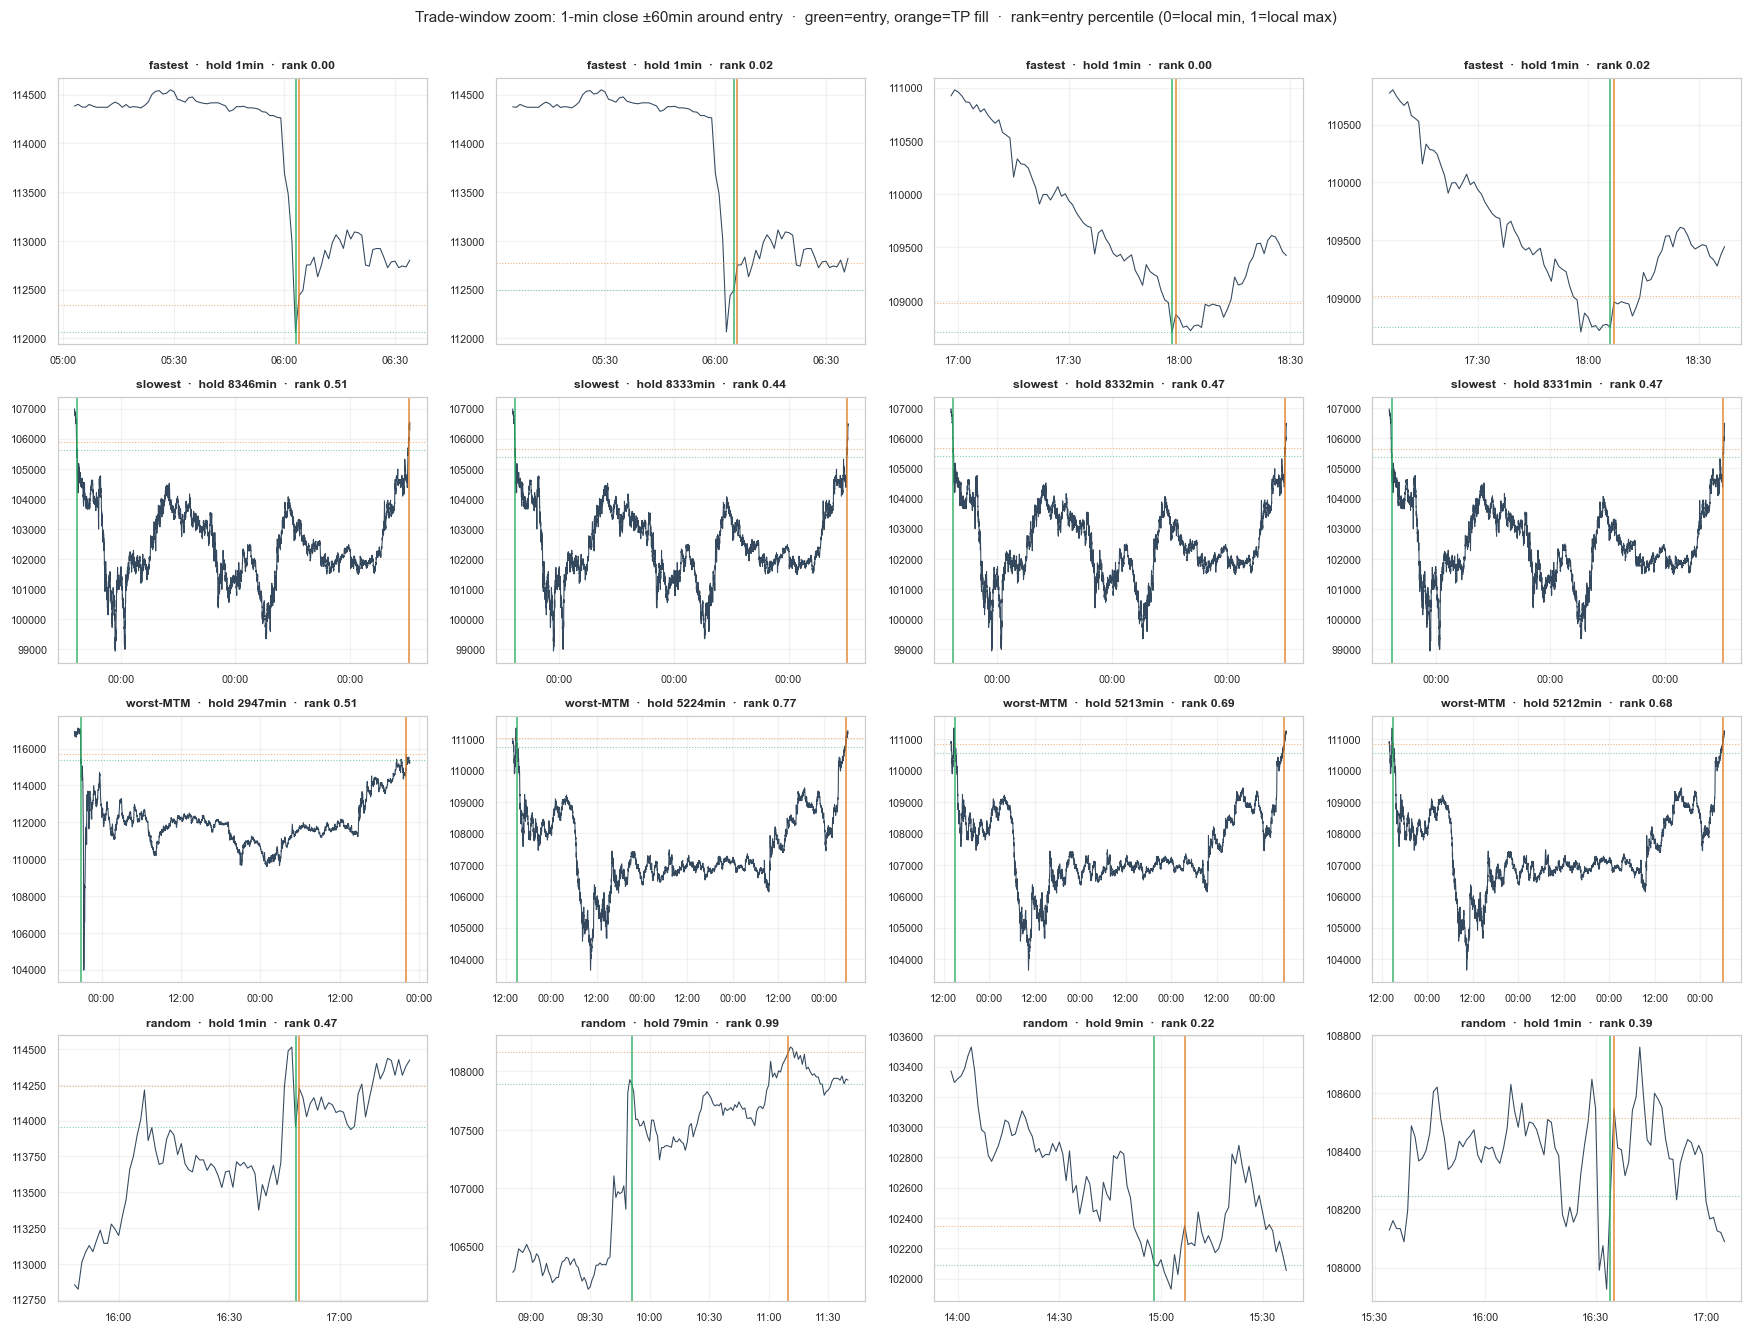

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\strategy\production_1min_selective\trade_zoom_grid.png


In [9]:
if len(sample) > 0:
    n_rows, n_cols = 4, 4
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12), sharey=False)
    raw_idx_local = raw_bars.index
    raw_close_arr = raw_bars['close'].to_numpy()
    for ax, (_, tr) in zip(axes.flat, sample.iterrows()):
        ts_in = pd.Timestamp(tr['ts_entry'])
        ts_out = pd.Timestamp(tr['ts_exit'])
        t0 = ts_in - pd.Timedelta(minutes=60)
        t1 = ts_out + pd.Timedelta(minutes=30)
        i0 = int(np.searchsorted(raw_idx_local, np.datetime64(t0), side='left'))
        i1 = int(np.searchsorted(raw_idx_local, np.datetime64(t1), side='right'))
        if i1 <= i0:
            ax.axis('off'); continue
        win_idx = raw_idx_local[i0:i1]
        win_close = raw_close_arr[i0:i1]
        ax.plot(win_idx, win_close, color='#34495e', linewidth=0.7)
        ax.axvline(ts_in, color='#27ae60', linewidth=1.0, alpha=0.9)
        ax.axvline(ts_out, color='#e67e22', linewidth=1.0, alpha=0.9)
        ax.axhline(float(tr['entry_price']), color='#27ae60', linestyle=':', linewidth=0.7, alpha=0.6)
        ax.axhline(float(tr['tp_price']), color='#e67e22', linestyle=':', linewidth=0.7, alpha=0.6)
        hold_min = (ts_out - ts_in).total_seconds() / 60.0
        ax.set_title(f"{tr.get('group','?')}  ·  hold {hold_min:.0f}min  ·  rank {tr.get('local_min_rank', np.nan):.2f}", fontsize=8)
        ax.tick_params(axis='x', rotation=0, labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=4))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.suptitle(
        'Trade-window zoom: 1-min close ±60min around entry  ·  green=entry, orange=TP fill  ·  rank=entry percentile (0=local min, 1=local max)',
        y=1.005, fontsize=10,
    )
    plt.tight_layout()
    fig.savefig(OUT_DIR / 'trade_zoom_grid.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUT_DIR / 'trade_zoom_grid.png'}")


## 7. Local-minimum-rank distribution (aggregate)

For every closed trade, rank the entry price within a ±60-minute window
around the entry. 0 = local min; 1 = local max. If the strategy is buying
dips, this should skew toward 0.


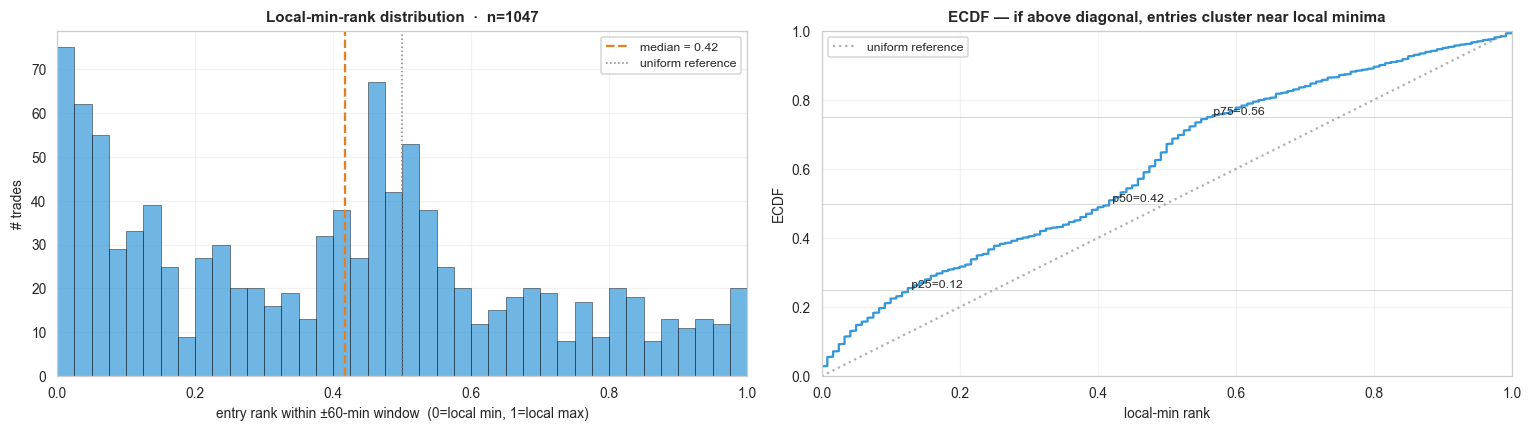

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\strategy\production_1min_selective\local_min_rank.png
median=0.42  mean=0.39  frac<0.5=64.76%


In [10]:
if len(closed):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    ranks = closed['local_min_rank'].dropna().to_numpy()

    axes[0].hist(ranks, bins=40, color='#3498db', alpha=0.7, edgecolor='black', linewidth=0.4)
    axes[0].axvline(np.median(ranks), color='#e67e22', linestyle='--', linewidth=1.5, label=f'median = {np.median(ranks):.2f}')
    axes[0].axvline(0.5, color='gray', linestyle=':', linewidth=1.0, label='uniform reference')
    axes[0].set_xlabel('entry rank within ±60-min window  (0=local min, 1=local max)')
    axes[0].set_ylabel('# trades')
    axes[0].set_title(f'Local-min-rank distribution  ·  n={len(ranks)}')
    axes[0].legend(); axes[0].set_xlim(0, 1)

    sorted_r = np.sort(ranks)
    ecdf = np.arange(1, len(sorted_r)+1) / len(sorted_r)
    axes[1].plot(sorted_r, ecdf, color='#3498db')
    axes[1].plot([0, 1], [0, 1], color='gray', linestyle=':', alpha=0.6, label='uniform reference')
    for q in [0.25, 0.5, 0.75]:
        v = float(np.quantile(ranks, q))
        axes[1].axhline(q, color='gray', linewidth=0.4, alpha=0.5)
        axes[1].text(v, q, f' p{int(q*100)}={v:.2f}', fontsize=8, va='bottom')
    axes[1].set_xlabel('local-min rank'); axes[1].set_ylabel('ECDF')
    axes[1].set_title('ECDF — if above diagonal, entries cluster near local minima')
    axes[1].legend(); axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

    plt.tight_layout()
    fig.savefig(OUT_DIR / 'local_min_rank.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUT_DIR / 'local_min_rank.png'}")

    rank_summary = {
        'n_trades': int(len(ranks)),
        'median': float(np.median(ranks)),
        'mean': float(np.mean(ranks)),
        'p25': float(np.quantile(ranks, 0.25)),
        'p75': float(np.quantile(ranks, 0.75)),
        'frac_below_0.25': float((ranks < 0.25).mean()),
        'frac_below_0.5': float((ranks < 0.5).mean()),
        'window_minutes': 60,
    }
    with open(OUT_DIR / 'local_min_rank_summary.json', 'w') as f:
        json.dump(rank_summary, f, indent=2)
    print(f"median={rank_summary['median']:.2f}  mean={rank_summary['mean']:.2f}  frac<0.5={rank_summary['frac_below_0.5']:.2%}")


## 8. Post-hoc characterization — hold-time and worst-MTM-per-position

Two distributions a live operator should be sized against. Both peek at
future paths; characterization, not decisions.


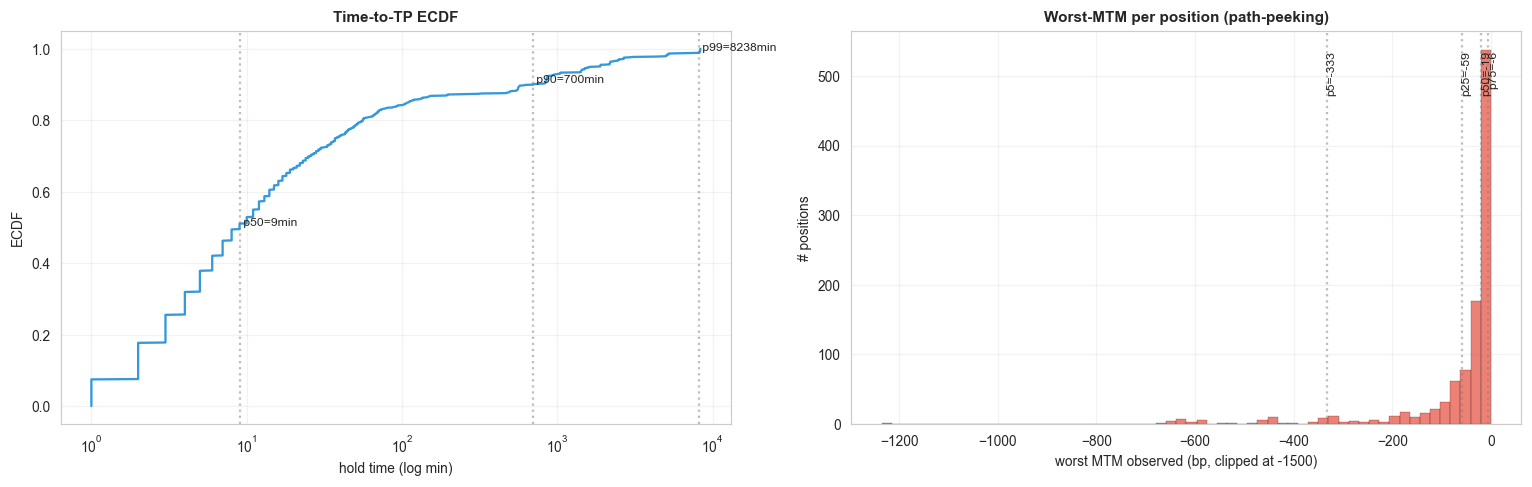

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\strategy\production_1min_selective\hold_and_worst_mtm.png
Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\strategy\production_1min_selective\closed_trades.parquet (1,047 rows)


In [11]:
if len(closed):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    closed['hold_minutes'] = (closed['ts_exit'] - closed['ts_entry']).dt.total_seconds() / 60.0

    sorted_h = np.sort(closed['hold_minutes'].to_numpy())
    ecdf = np.arange(1, len(sorted_h)+1) / len(sorted_h)
    axes[0].semilogx(sorted_h, ecdf, color='#3498db')
    for q, lab in [(0.50, 'p50'), (0.90, 'p90'), (0.99, 'p99')]:
        v = float(np.quantile(closed['hold_minutes'], q))
        axes[0].axvline(v, color='gray', linestyle=':', alpha=0.5)
        axes[0].text(v, q, f' {lab}={v:.0f}min', verticalalignment='bottom', fontsize=8)
    axes[0].set_xlabel('hold time (log min)'); axes[0].set_ylabel('ECDF')
    axes[0].set_title('Time-to-TP ECDF')

    raw_idx_local = raw_bars.index
    raw_low_arr = raw_bars['low'].to_numpy()
    worst = []
    for _, row in closed.iterrows():
        lo = int(np.searchsorted(raw_idx_local, np.datetime64(row['ts_entry']), side='right'))
        hi = int(np.searchsorted(raw_idx_local, np.datetime64(row['ts_exit']), side='right'))
        if hi <= lo:
            worst.append(0.0); continue
        worst.append(float(np.log(raw_low_arr[lo:hi].min() / row['entry_price'])))
    closed['worst_mtm_bp'] = np.asarray(worst) * 10000.0
    axes[1].hist(closed['worst_mtm_bp'].clip(lower=-1500, upper=0), bins=60,
                 color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=0.2)
    for q in [0.05, 0.25, 0.50, 0.75]:
        v = float(closed['worst_mtm_bp'].quantile(q))
        axes[1].axvline(v, color='gray', linestyle=':', alpha=0.5)
        axes[1].text(v, axes[1].get_ylim()[1]*0.95, f'p{int(q*100)}={v:.0f}', rotation=90, va='top', fontsize=8)
    axes[1].set_xlabel('worst MTM observed (bp, clipped at -1500)')
    axes[1].set_ylabel('# positions')
    axes[1].set_title('Worst-MTM per position (path-peeking)')

    plt.tight_layout()
    fig.savefig(OUT_DIR / 'hold_and_worst_mtm.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUT_DIR / 'hold_and_worst_mtm.png'}")

    closed.to_parquet(OUT_DIR / 'closed_trades.parquet', index=False)
    print(f"Saved: {OUT_DIR / 'closed_trades.parquet'} ({len(closed):,} rows)")


## 9. Sensitivity to `UNC_Q_COND`

Re-run across a small grid of conditional-quantile choices. Smaller q =
stricter epistemic filter, fewer trades. Shows whether tightening the
unc gate trades volume for quality.


In [12]:
rows = []
for q in [0.25, 0.40, 0.50, 0.65, 0.80, 1.00]:
    u_cap = derive_conditional_unc_cap(p_train, unc_train, p_threshold=P_95, q=q)
    sp = StrategySpec(
        name=f'sweep_unc_q_{q}',
        requires=('ve_diag',),
        score_fn=score_raw_p,
        entry_gates=(
            lambda s, t=P_95: gate_score_above(s, t),
            lambda s, c=u_cap: gate_knowledge_unc_cap(s, c),
        ),
        sizer=lambda s, sz=LOT_SIZE: size_clip(size_constant(s, default=sz), max_size=1.0),
        exit_policy=exit_tp_or_expiry,
        bulk_close=lambda s: None,
        risk=RiskConfig(
            cost_per_trade=COST,
            max_open_positions=MAX_CONCURRENT,
            max_gross_size=MAX_CONCURRENT * LOT_SIZE + 1e-6,
            max_horizon_boundaries=MAX_HORIZON_BOUNDARIES,
        ),
    )
    rr = simulate(sim_cache, raw_bars, sp, config=cfg)
    n_sig = int(rr.equity['opened_this_step'].sum())
    n_tp = int((rr.closed['exit_reason']=='tp').sum()) if len(rr.closed) else 0
    realized_pct = float(rr.equity['realized_cum'].iloc[-1]) * 100
    min_unreal_pct = float(rr.equity['unrealized'].min()) * 100
    rows.append({
        'unc_q': q, 'U_cap_bp': u_cap * 1e4,
        'signals': n_sig, 'TPs': n_tp, 'open_at_end': int(rr.equity['n_open'].iloc[-1]),
        'realized_pct': realized_pct, 'min_unrealized_pct': min_unreal_pct,
    })
sweep_df = pd.DataFrame(rows)
display(sweep_df.style.format({
    'U_cap_bp': '{:.4f}', 'realized_pct': '{:+.3f}', 'min_unrealized_pct': '{:+.3f}',
}).hide(axis='index'))
sweep_df.to_csv(OUT_DIR / 'unc_q_sweep.csv', index=False)
print(f"Saved: {OUT_DIR / 'unc_q_sweep.csv'}")


unc_q,U_cap_bp,signals,TPs,open_at_end,realized_pct,min_unrealized_pct
0.250000,0.0000,1097,1047,50,+4.188,-31.969
0.400000,0.0000,1097,1047,50,+4.188,-31.969
0.500000,0.0000,1097,1047,50,+4.188,-31.969
0.650000,0.0000,1097,1047,50,+4.188,-31.969
0.800000,30.6892,1140,1090,50,+4.360,-31.969
1.000000,1156.9071,1107,1057,50,+4.228,-31.969


Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\strategy\production_1min_selective\unc_q_sweep.csv


## 10. Closing notes

**Claims**
- Both gates use thresholds *frozen on training data only*. Val/test never
  influenced the strategy's parameters.
- The simulator is bit-equivalent to a live operator placing GTC TP limit
  orders at +phi on every fire.
- Strategy never closes at a loss: no SL, no bulk-close, no horizon.

**Limits**
- The training-period HPO leak from notebook 03 still applies — the gate
  thresholds are frozen on train, but the model itself wasn't trained
  under nested CV. Separate piece of work.
- No walk-forward refresh of `(P_95, U_cap)`. In production these should
  be re-derived monthly from the trailing training-period score+unc joint.
- The strategy is **structurally long-biased**, not delta-neutral. Realized
  P&L can be positive in a falling market only at the cost of carrying
  underwater inventory. Read realized + unrealized together.
